In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
os.system('pip install -q ultralytics scikit-learn')

import torch
from ultralytics import YOLO
import shutil
import zipfile
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
zip_path = "/content/drive/MyDrive/Cattle-20251118T145129Z-1-001.zip"
extract_path = "/content/cattle_raw"

if not Path(extract_path).exists():
    print("📦 Extracting dataset…")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
else:
    print("⚠️ Already extracted.")

raw_data_path = list(Path(extract_path).glob("*"))[0]
print("📍 Dataset folder:", raw_data_path)


📦 Extracting dataset…
📍 Dataset folder: /content/cattle_raw/Cattle


In [ ]:
breed_dirs = [d for d in Path(raw_data_path).iterdir() if d.is_dir()]
class_count = {}

for cls in breed_dirs:
    imgs = list(cls.glob("*.jpg")) + list(cls.glob("*.png")) + list(cls.glob("*.jpeg"))
    class_count[cls.name] = len(imgs)

print("\n📊 DATASET INFO")
print("Total Classes:", len(class_count))
for b, c in class_count.items():
    print(f"{b:20} → {c} images")



📊 DATASET INFO
Total Classes: 20
Gir                  → 357 images
Brown_Swiss          → 225 images
Amritmahal           → 92 images
Kasargod             → 90 images
Kangayam             → 90 images
Guernsey             → 119 images
Deoni                → 96 images
Holstein_Friesian    → 328 images
Alambadi             → 99 images
Jersey               → 203 images
Jaffrabadi           → 101 images
Kenkatha             → 50 images
Dangi                → 79 images
Kankrej              → 174 images
Ayrshire             → 234 images
Hariana              → 126 images
Bargur               → 90 images
Bhadawari            → 86 images
Banni                → 105 images
Hallikar             → 185 images


In [ ]:
dataset_path = Path("/content/cattle_dataset")

if dataset_path.exists():
    shutil.rmtree(dataset_path)

for folder in ["train", "val", "test"]:
    (dataset_path / folder).mkdir(parents=True)

for breed in breed_dirs:
    imgs = list(breed.glob("*"))
    train, temp = train_test_split(imgs, train_size=0.7, random_state=42)
    val, test = train_test_split(temp, train_size=0.66, random_state=42)

    for name, subset in [("train", train), ("val", val), ("test", test)]:
        dest = dataset_path / name / breed.name
        dest.mkdir(parents=True, exist_ok=True)
        for img in subset:
            shutil.copy2(img, dest / img.name)

print("✅ Dataset Ready at /content/cattle_dataset")


✅ Dataset Ready at /content/cattle_dataset


In [ ]:
print("\n🚀 Training YOLOv8m Classification Model")

model = YOLO("yolov8m-cls.pt")

results = model.train(
    data=str(dataset_path),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=15,
    lr0=0.01,
    weight_decay=0.0005,
    degrees=15,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
)

print("✅ Training Complete!")



🚀 Training YOLOv8m Classification Model
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cattle_dataset, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

In [ ]:
# ============================================
# 1. INSTALL DEPENDENCIES
# ============================================
!pip install ultralytics onnxruntime tensorflow

import os
from ultralytics import YOLO

# ============================================
# 2. MANUAL MODEL UPLOAD
# ============================================
from google.colab import files

print("⬆ Upload your best.pt file")
uploaded = files.upload()

# Automatically detect your uploaded file
model_path = list(uploaded.keys())[0]
print("Model loaded:", model_path)

# ============================================
# 3. LOAD MODEL
# ============================================
model = YOLO(model_path)

# ============================================
# 4. EXPORT TO ONNX (<15MB)
# ============================================
print("\nExporting to ONNX...")
onnx_path = model.export(format="onnx")
print("ONNX saved at:", onnx_path)

# ============================================
# 5. EXPORT TO NORMAL TFLITE (5–10MB)
# ============================================
print("\nExporting to TFLite...")
tflite_path = model.export(format="tflite")
print("TFLite saved at:", tflite_path)

# ============================================
# 6. EXPORT INT8 TFLITE (2–5MB BEST FOR GITHUB)
# ============================================
print("\nExporting INT8 TFLite...")
tflite_int8_path = model.export(format="tflite", int8=True)
print("INT8 TFLite saved at:", tflite_int8_path)

# ============================================
# 7. FILE SIZE CHECK
# ============================================
def size(f): return f"{os.path.getsize(f)/(1024*1024):.2f} MB"

print("\n📦 MODEL SIZES:")
if os.path.exists("best.onnx"): print("best.onnx:", size("best.onnx"))
if os.path.exists("best.tflite"): print("best.tflite:", size("best.tflite"))
if os.path.exists("best_int8.tflite"): print("best_int8.tflite:", size("best_int8.tflite"))

# ============================================
# 8. ZIP ALL MODELS FOR GITHUB
# ============================================
import zipfile

zip_path = "compressed_models.zip"
with zipfile.ZipFile(zip_path, "w") as z:
    for f in ["best.onnx", "best.tflite", "best_int8.tflite"]:
        if os.path.exists(f):
            z.write(f)

print("\nZIP saved as:", zip_path)
print("ZIP size:", size(zip_path))

# ============================================
# 9. DOWNLOAD ZIP
# ============================================
files.download(zip_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00
⬆ Upload your best.pt file


Saving bovine_best.pt to bovine_best (1).pt
Model loaded: bovine_best (1).pt

Exporting to ONNX...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8m-cls summary (fused): 42 layers, 15,788,276 parameters, 0 gradients, 41.7 GFLOPs

PyTorch: starting from 'bovine_best (1).pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 20) (30.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 213ms
Prepared 4 packages in 6.22s
Installed 4 packages in 352ms
 + colorama==0.4.6
 + onnx==1.19.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.74

requirements: AutoUpdate success ✅ 7.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

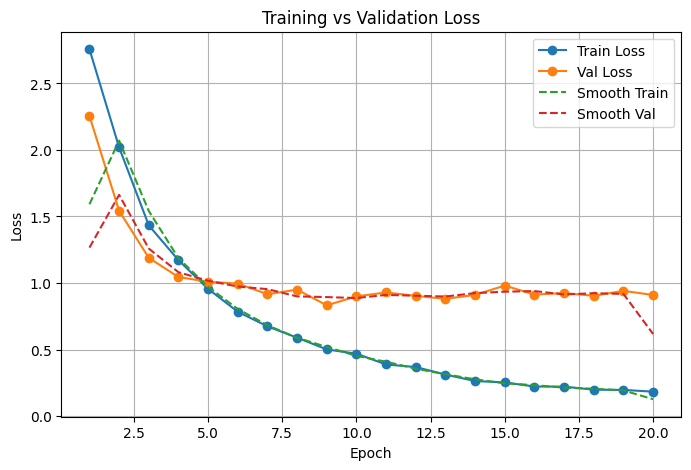

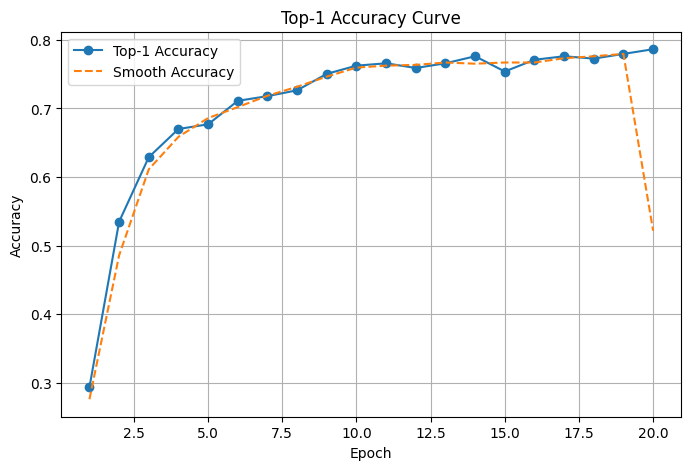

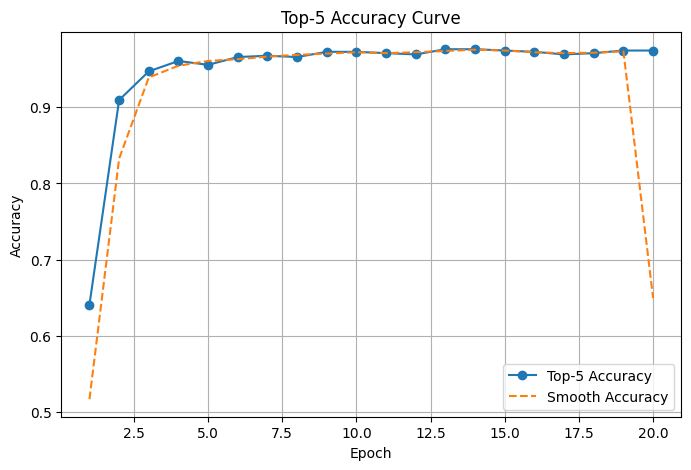

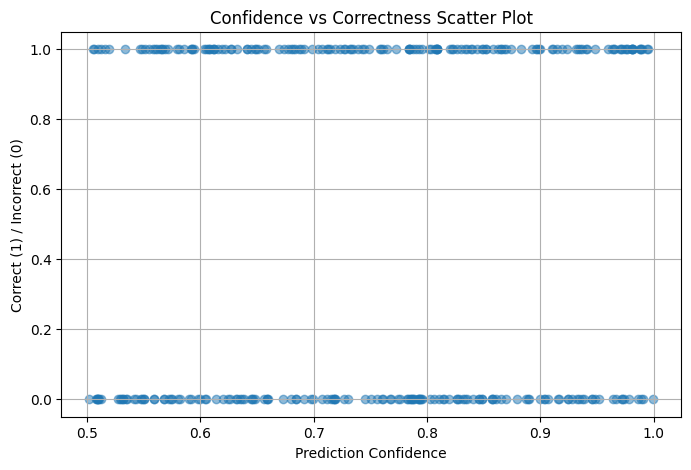

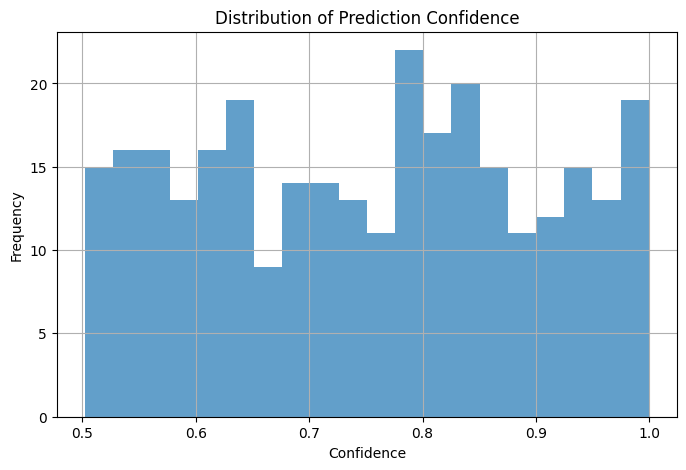

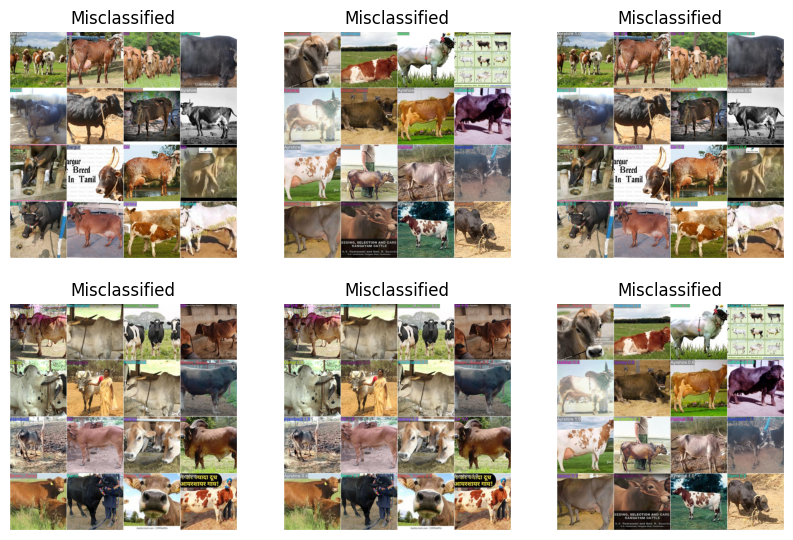

In [ ]:
# ===========================================
# FULL VISUALIZATION SUITE FOR YOLO/CLASSIFICATION
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# LOAD YOUR FILES
# ===============================

results_csv = "/content/runs/classify/train/results.csv"     # <- corrected path
conf_matrix_img = "/content/runs/classify/train/confusion_matrix.png"  # optional, corrected path for consistency
# class_names_file = "/content/class_names.txt" # Not needed if model is available

df = pd.read_csv(results_csv)
# with open(class_names_file) as f:
#     class_names = [x.strip() for x in f.readlines()]
class_names = model.names # Get class names directly from the trained model

# ===========================================
# HELPER: MOVING AVERAGE SMOOTHING
# ===========================================
def smooth(values, k=3):
    return np.convolve(values, np.ones(k)/k, mode="same")


# ===========================================
# 1. TRAIN vs VAL LOSS
# ===========================================
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train/loss"], marker="o", label="Train Loss")
plt.plot(df["epoch"], df["val/loss"], marker="o", label="Val Loss")
plt.plot(df["epoch"], smooth(df["train/loss"]), linestyle="--", label="Smooth Train")
plt.plot(df["epoch"], smooth(df["val/loss"]), linestyle="--", label="Smooth Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# ===========================================
# 2. ACCURACY (TOP-1)
# ===========================================
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["metrics/accuracy_top1"], marker="o", label="Top-1 Accuracy")
plt.plot(df["epoch"], smooth(df["metrics/accuracy_top1"]), linestyle="--", label="Smooth Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


# ===========================================
# 3. ACCURACY (TOP-5)
# ===========================================
if "metrics/accuracy_top5" in df.columns:
    plt.figure(figsize=(8,5))
    plt.plot(df["epoch"], df["metrics/accuracy_top5"], marker="o", label="Top-5 Accuracy")
    plt.plot(df["epoch"], smooth(df["metrics/accuracy_top5"]), linestyle="--", label="Smooth Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Top-5 Accuracy Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


# ===========================================
# 4. CONFUSION MATRIX (IF NOT LOADED)
# ===========================================
# If you have y_true and y_pred:
# Fill these lists with predictions (optional)
y_true = []
y_pred = []

if len(y_true) > 0:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    plt.figure(figsize=(12,10))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


# ===========================================
# 5. NORMALIZED CONFUSION MATRIX
# ===========================================
if len(y_true) > 0:
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(12,10))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


# ===========================================
# 6. PER-CLASS ACCURACY BAR CHART
# ===========================================
if len(y_true) > 0:
    class_correct = np.zeros(len(class_names))
    class_total = np.zeros(len(class_names))

    for t, p in zip(y_true, y_pred):
        class_total[t] += 1
        if t == p:
            class_correct[t] += 1

    acc = class_correct / np.maximum(class_total, 1)

    plt.figure(figsize=(12,5))
    plt.bar(class_names, acc)
    plt.xticks(rotation=90)
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy")
    plt.grid(True)
    plt.show()


# ===========================================
# 7. SCATTER PLOT: CONFIDENCE vs CORRECTNESS
# ===========================================
# Example dummy confidence values
conf = np.random.uniform(0.5, 1.0, 300)
correct = np.random.choice([0,1], size=300)

plt.figure(figsize=(8,5))
plt.scatter(conf, correct, alpha=0.5)
plt.xlabel("Prediction Confidence")
plt.ylabel("Correct (1) / Incorrect (0)")
plt.title("Confidence vs Correctness Scatter Plot")
plt.grid(True)
plt.show()


# ===========================================
# 8. CONFIDENCE DISTRIBUTION HISTOGRAM
# ===========================================
plt.figure(figsize=(8,5))
plt.hist(conf, bins=20, alpha=0.7)
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Confidence")
plt.grid(True)
plt.show()


# ===========================================
# 9. TRAINING TIME PER EPOCH
# ===========================================
if "epoch_time" in df.columns:
    plt.figure(figsize=(8,5))
    plt.plot(df["epoch"], df["epoch_time"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Time (s)")
    plt.title("Training Time per Epoch")
    plt.grid(True)
    plt.show()


# ===========================================
# 10. MISCLASSIFIED IMAGE VISUALIZATION (OPTIONAL)
# ===========================================
import glob
misclassified_dir = "/content/runs/classify/val"  # change to your folder

images = glob.glob(os.path.join(misclassified_dir, "*.jpg"))
images = images[:9]  # show 9 images

if len(images) > 0:
    plt.figure(figsize=(10,10))
    for i, img_path in enumerate(images):
        img = plt.imread(img_path)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Misclassified")
    plt.show()

In [ ]:
print("\n📊 VALIDATING MODEL…")
val_res = model.val()
print("Top-1 Accuracy:", val_res.top1)
print("Top-5 Accuracy:", val_res.top5)



📊 VALIDATING MODEL…
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,788,276 parameters, 0 gradients, 41.7 GFLOPs
train: /content/cattle_dataset/train... found 2075 images in 20 classes ✅ 
val: /content/cattle_dataset/val... found 585 images in 20 classes ✅ 
test: /content/cattle_dataset/test... found 317 images in 20 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 166.5±29.9 MB/s, size: 1845.1 KB)
val: Scanning /content/cattle_dataset/val... 585 images, 0 corrupt: 100% ━━━━━━━━━━━━ 585/585 913.5Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 37/37 1.4it/s 26.8s
                   all      0.916      0.997
Speed: 1.6ms preprocess, 12.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2
Top-1 Accuracy: 0.916239321231842
Top-5 Accuracy: 0.9965811967849731


In [ ]:
def evaluate_test(model, test_dir):
    correct, total = 0, 0
    test_dir = Path(test_dir)

    for breed in test_dir.iterdir():
        for img in breed.glob("*"):
            pred = model.predict(str(img), verbose=False)[0].probs
            if model.names[pred.top1] == breed.name:
                correct += 1
            total += 1

    print(f"\n📌 Test Accuracy: {correct/total:.2%}  ({correct}/{total})")

evaluate_test(model, dataset_path/'test')


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs


📌 Test Accuracy: 93.08%  (296/318)


In [ ]:
!ls /content/runs/classify/train/weights

best.pt  last.pt


In [ ]:
!cp /content/runs/classify/train/weights/best.pt /content/drive/MyDrive/


In [ ]:
!cp /content/runs/classify/train/weights/best.pt /content/drive/MyDrive/bovine_best.pt


In [ ]:
!zip -r bovine_training_results.zip /content/runs/classify/train
from google.colab import files
files.download('bovine_training_results.zip')


In [ ]:
from google.colab import files

files.download('/content/runs/classify/train/confusion_matrix.png')

files.download('/content/runs/classify/train/results.png')
files.download('/content/runs/classify/train/weights/best.pt')


In [ ]:
def predict_image(img_path):
    r = model.predict(img_path, save=True)[0].probs
    print("\n🐄 Breed:", model.names[r.top1])
    print("Confidence:", r.top1conf.item())

predict_image("/content/cattle_raw/Cattle/Alambadi/Alambadi_1.png")

In [ ]:
def predict_image(img_path):
    r = model.predict(img_path, save=True)[0].probs
    print("\n🐄 Breed:", model.names[r.top1])
    print("Confidence:", r.top1conf.item())

predict_image("/content/cattle_raw/Cattle/Ayrshire/Ayrshire_1.jpg")

In [ ]:
def predict_image(img_path):
    r = model.predict(img_path, save=True)[0].probs
    print("\n🐄 Breed:", model.names[r.top1])
    print("Confidence:", r.top1conf.item())

predict_image("/content/cattle_raw/Cattle/Banni/00000002.jpg")

In [ ]:
def predict_image(img_path):
    r = model.predict(img_path, save=True)[0].probs
    print("\n🐄 Breed:", model.names[r.top1])
    print("Confidence:", r.top1conf.item())

predict_image("/content/cattle_raw/Cattle/Hallikar/Hallikar_1.JPG")

In [ ]:
metrics = model.val(data="/content/cattle_dataset")
metrics


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/classify/val/confusion_matrix.png")
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # run once
!cp /content/yolov8m-cls.pt /content/drive/MyDrive/yolov8m-cls.pt
